**Data Analysis for Business**



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from scipy import stats
print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
df = pd.read_csv('credit_risk_dataset.csv')
print(f"✅ Dataset loaded! Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Missing values:\n{df.isnull().sum()}")

✅ Dataset loaded! Shape: 32581 rows, 12 columns
Missing values:
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


Exploratory charts

/tmp/ipykernel_60600/291603049.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot(


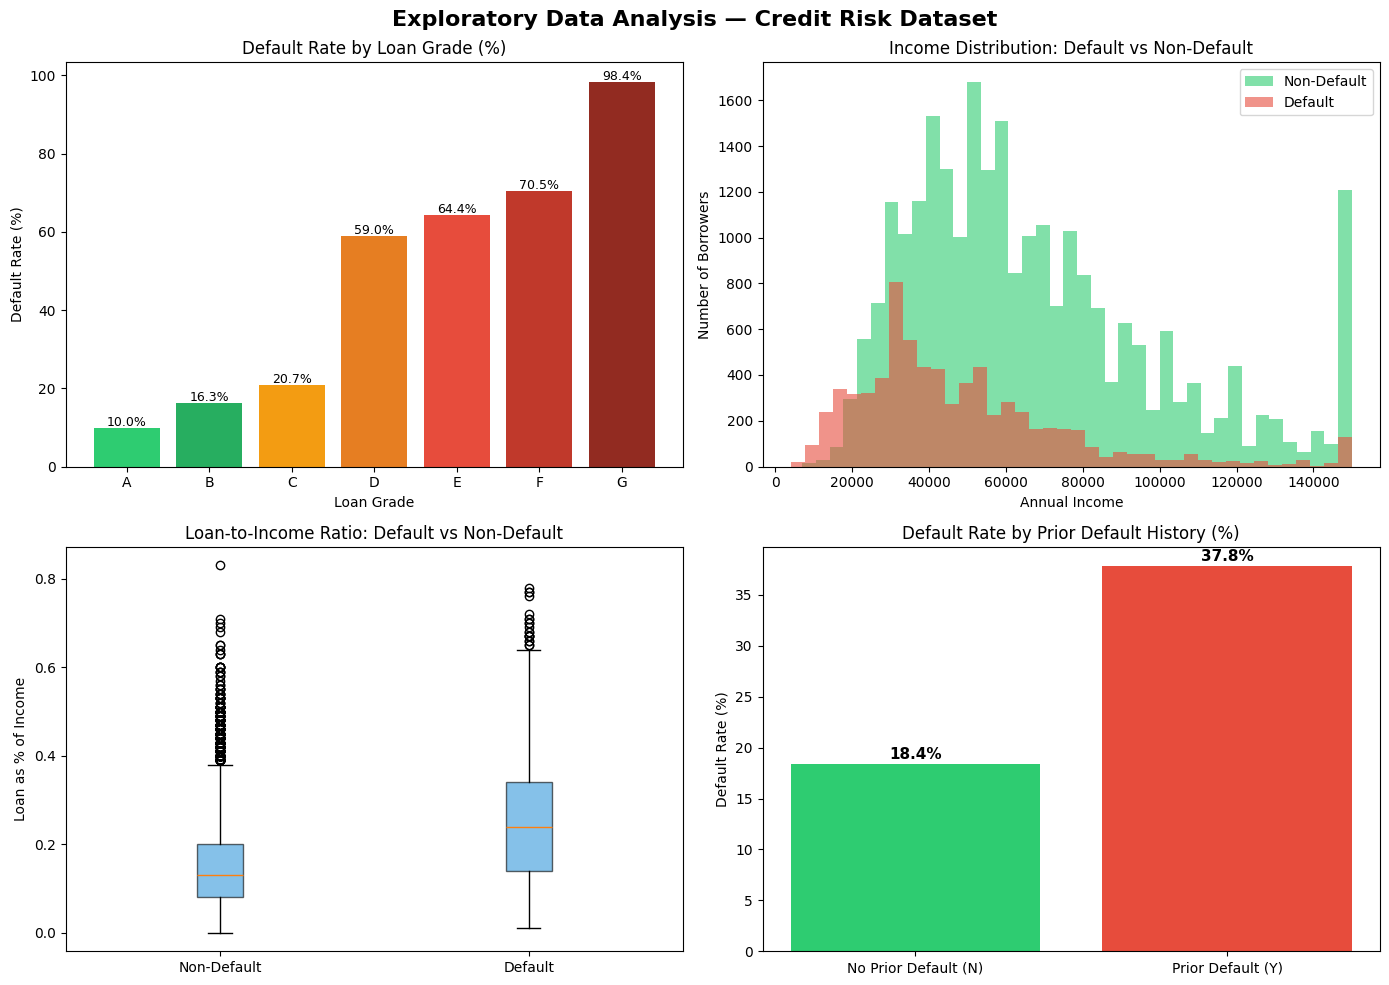

Exploratory charts done!


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Exploratory Data Analysis — Credit Risk Dataset', fontsize=16, fontweight='bold')

grade_default = df.groupby('loan_grade')['loan_status'].mean() * 100
axes[0, 0].bar(grade_default.index, grade_default.values, color=['#2ecc71','#27ae60','#f39c12','#e67e22','#e74c3c','#c0392b','#922b21'])
axes[0, 0].set_title('Default Rate by Loan Grade (%)')
axes[0, 0].set_xlabel('Loan Grade')
axes[0, 0].set_ylabel('Default Rate (%)')
for i, v in enumerate(grade_default.values):
    axes[0, 0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)

default_income = df[df['loan_status'] == 1]['person_income']
non_default_income = df[df['loan_status'] == 0]['person_income']
axes[0, 1].hist(non_default_income.clip(upper=150000), bins=40, alpha=0.6, label='Non-Default', color='#2ecc71')
axes[0, 1].hist(default_income.clip(upper=150000), bins=40, alpha=0.6, label='Default', color='#e74c3c')
axes[0, 1].set_title('Income Distribution: Default vs Non-Default')
axes[0, 1].set_xlabel('Annual Income')
axes[0, 1].set_ylabel('Number of Borrowers')
axes[0, 1].legend()

axes[1, 0].boxplot(
    [df[df['loan_status'] == 0]['loan_percent_income'], df[df['loan_status'] == 1]['loan_percent_income']],
    labels=['Non-Default', 'Default'], patch_artist=True,
    boxprops=dict(facecolor='#3498db', alpha=0.6))
axes[1, 0].set_title('Loan-to-Income Ratio: Default vs Non-Default')
axes[1, 0].set_ylabel('Loan as % of Income')

prior_default = df.groupby('cb_person_default_on_file')['loan_status'].mean() * 100
axes[1, 1].bar(['No Prior Default (N)', 'Prior Default (Y)'], prior_default.values, color=['#2ecc71', '#e74c3c'])
axes[1, 1].set_title('Default Rate by Prior Default History (%)')
axes[1, 1].set_ylabel('Default Rate (%)')
for i, v in enumerate(prior_default.values):
    axes[1, 1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('exploratory_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Exploratory charts done!")

Clean and prepare data

In [ ]:
print(f"Original size: {len(df)} rows")
df_clean = df.dropna()
df_clean = df_clean[df_clean['person_age'] <= 80]
print(f"After cleaning: {len(df_clean)} rows")

le = LabelEncoder()
for col in ['loan_grade', 'loan_intent', 'cb_person_default_on_file']:
    df_clean[col] = le.fit_transform(df_clean[col])

feature_cols = ['person_age', 'person_income', 'person_emp_length',
                'loan_amnt', 'loan_int_rate', 'loan_grade',
                'loan_percent_income', 'cb_person_default_on_file']
X = df_clean[feature_cols]
y = df_clean['loan_status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set: {len(X_train)} rows | Testing set: {len(X_test)} rows")
print("Data preparation complete!")

Original size: 32581 rows
After cleaning: 28633 rows
Training set: 22906 rows | Testing set: 5727 rows
Data preparation complete!


Logistic Regression


METHOD 1: LOGISTIC REGRESSION


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 84.09%
              precision    recall  f1-score   support

 Non-Default       0.86      0.95      0.90      4513
     Default       0.70      0.44      0.54      1214

    accuracy                           0.84      5727
   macro avg       0.78      0.69      0.72      5727
weighted avg       0.83      0.84      0.83      5727



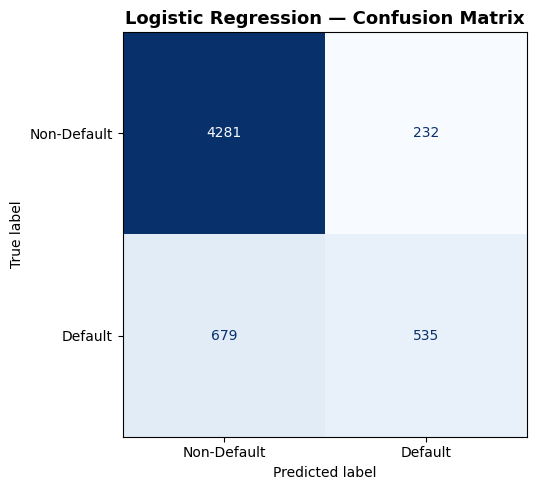


Feature Coefficients:
                  Feature  Coefficient
      loan_percent_income    10.300841
               loan_grade     0.705548
cb_person_default_on_file    -0.138986
            loan_int_rate     0.081679
        person_emp_length    -0.022664
               person_age     0.008683
                loan_amnt    -0.000069
            person_income    -0.000003


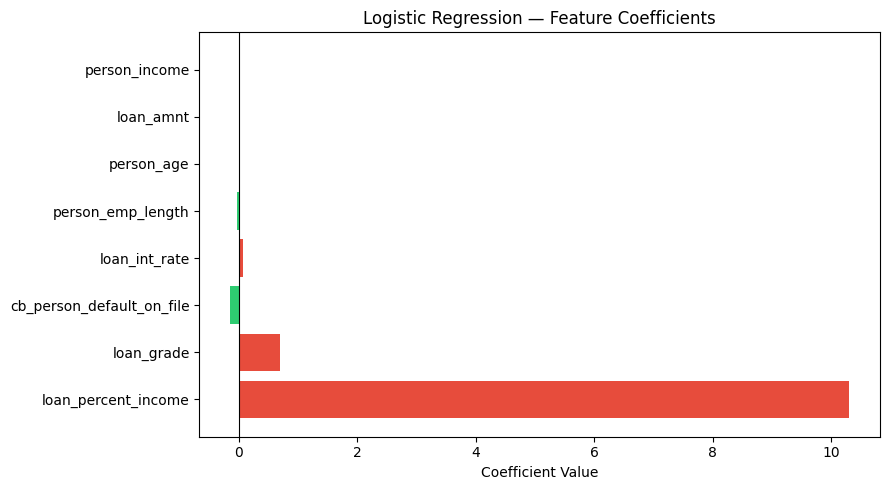

In [ ]:
print("\n" + "="*50)
print("METHOD 1: LOGISTIC REGRESSION")
print("="*50)
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_predictions)
print(f"Accuracy: {round(lr_accuracy * 100, 2)}%")
print(classification_report(y_test, lr_predictions, target_names=['Non-Default', 'Default']))

cm_lr = confusion_matrix(y_test, lr_predictions)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Non-Default', 'Default'])
fig, ax = plt.subplots(figsize=(7, 5))
disp_lr.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Logistic Regression — Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('logistic_regression_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

coef_df = pd.DataFrame({'Feature': feature_cols, 'Coefficient': lr_model.coef_[0]}).sort_values('Coefficient', key=abs, ascending=False)
print("\nFeature Coefficients:")
print(coef_df.to_string(index=False))

plt.figure(figsize=(9, 5))
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Logistic Regression — Feature Coefficients')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('logistic_regression_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

Decision Tree


METHOD 2: DECISION TREE CLASSIFIER
Accuracy: 87.29%
              precision    recall  f1-score   support

 Non-Default       0.90      0.94      0.92      4513
     Default       0.74      0.63      0.68      1214

    accuracy                           0.87      5727
   macro avg       0.82      0.78      0.80      5727
weighted avg       0.87      0.87      0.87      5727



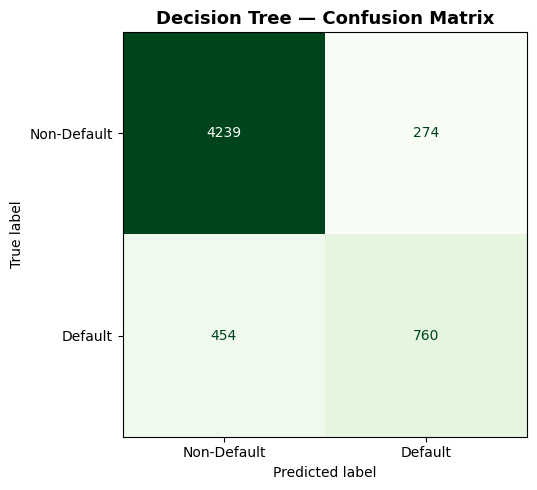


Feature Importance:
                  Feature  Importance
      loan_percent_income    0.449445
               loan_grade    0.364972
            person_income    0.121902
        person_emp_length    0.055615
            loan_int_rate    0.005860
                loan_amnt    0.002206
               person_age    0.000000
cb_person_default_on_file    0.000000


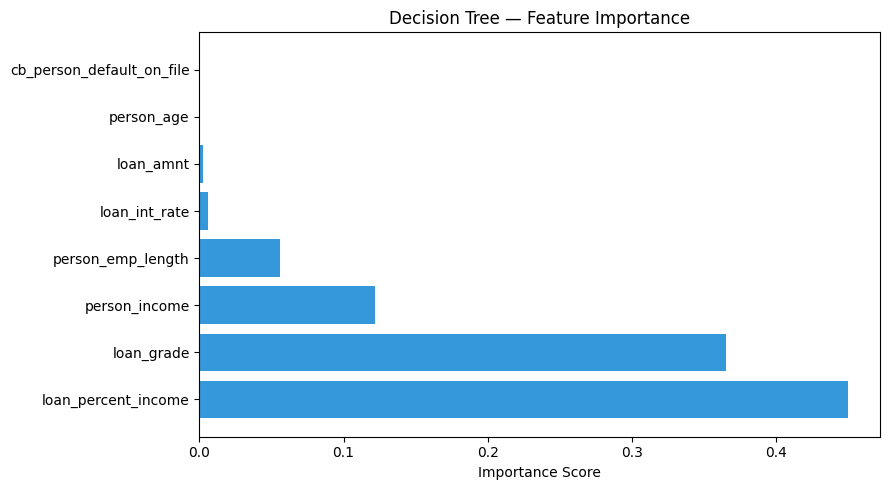

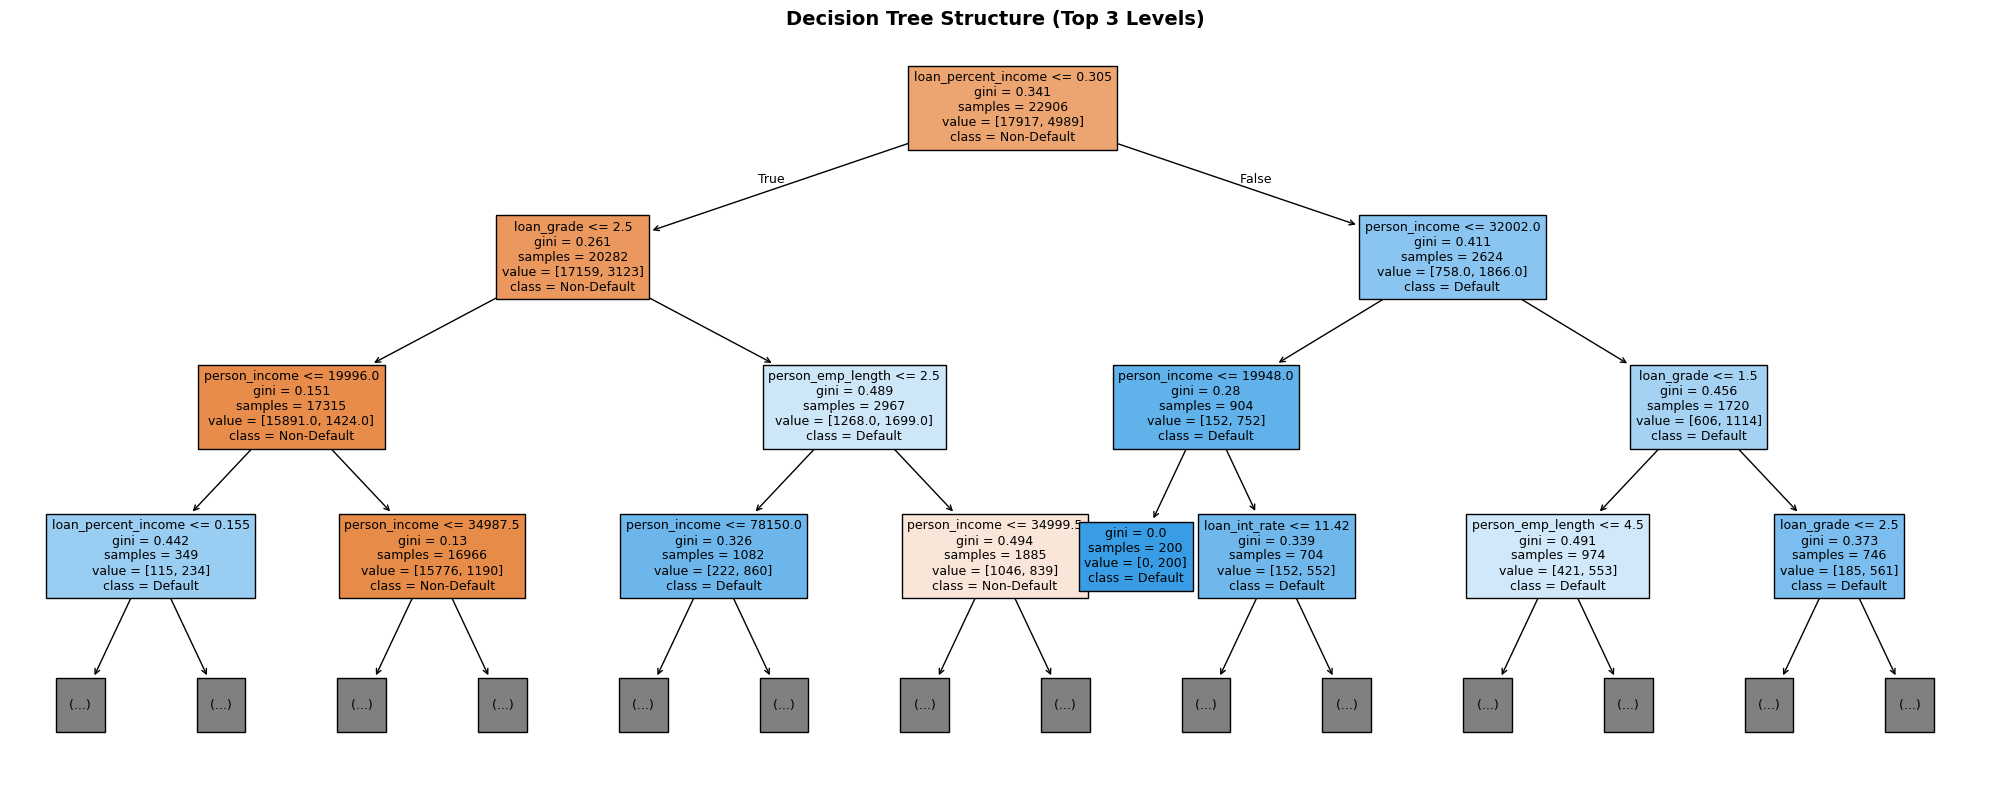

In [ ]:
print("\n" + "="*50)
print("METHOD 2: DECISION TREE CLASSIFIER")
print("="*50)
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
dt_predictions = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_predictions)
print(f"Accuracy: {round(dt_accuracy * 100, 2)}%")
print(classification_report(y_test, dt_predictions, target_names=['Non-Default', 'Default']))

cm_dt = confusion_matrix(y_test, dt_predictions)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=['Non-Default', 'Default'])
fig, ax = plt.subplots(figsize=(7, 5))
disp_dt.plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title('Decision Tree — Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('decision_tree_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

importance_df = pd.DataFrame({'Feature': feature_cols, 'Importance': dt_model.feature_importances_}).sort_values('Importance', ascending=False)
print("\nFeature Importance:")
print(importance_df.to_string(index=False))

plt.figure(figsize=(9, 5))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='#3498db')
plt.title('Decision Tree — Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('decision_tree_importance.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(20, 8))
plot_tree(dt_model, feature_names=feature_cols, class_names=['Non-Default', 'Default'], filled=True, max_depth=3, fontsize=9)
plt.title('Decision Tree Structure (Top 3 Levels)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('decision_tree_structure.png', dpi=150, bbox_inches='tight')
plt.show()

Model Comparison


MODEL COMPARISON
Logistic Regression: 84.09%
Decision Tree:       87.29%


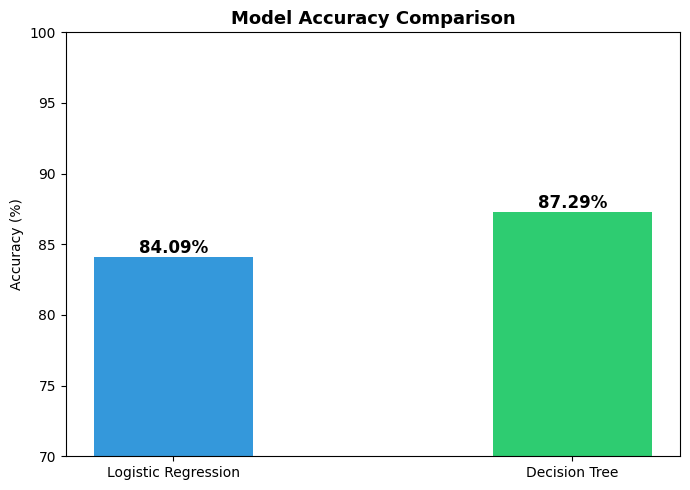

In [ ]:
print("\n" + "="*50)
print("MODEL COMPARISON")
print("="*50)
print(f"Logistic Regression: {round(lr_accuracy * 100, 2)}%")
print(f"Decision Tree:       {round(dt_accuracy * 100, 2)}%")

plt.figure(figsize=(7, 5))
bars = plt.bar(['Logistic Regression', 'Decision Tree'],
               [round(lr_accuracy * 100, 2), round(dt_accuracy * 100, 2)],
               color=['#3498db', '#2ecc71'], width=0.4)
plt.ylim(70, 100)
plt.title('Model Accuracy Comparison', fontsize=13, fontweight='bold')
plt.ylabel('Accuracy (%)')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{bar.get_height():.2f}%', ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Hypothesis Testing


HYPOTHESIS TESTING (t-test)
Mean income — Non-Default borrowers: £70,958
Mean income — Default borrowers:     £50,055

t-statistic: 28.6681
p-value:     0.000000

p-value (0.000000) < 0.05 — REJECT the null hypothesis.
There IS a statistically significant difference in income between
defaulting and non-defaulting borrowers.
Income is a genuine predictor of default risk.


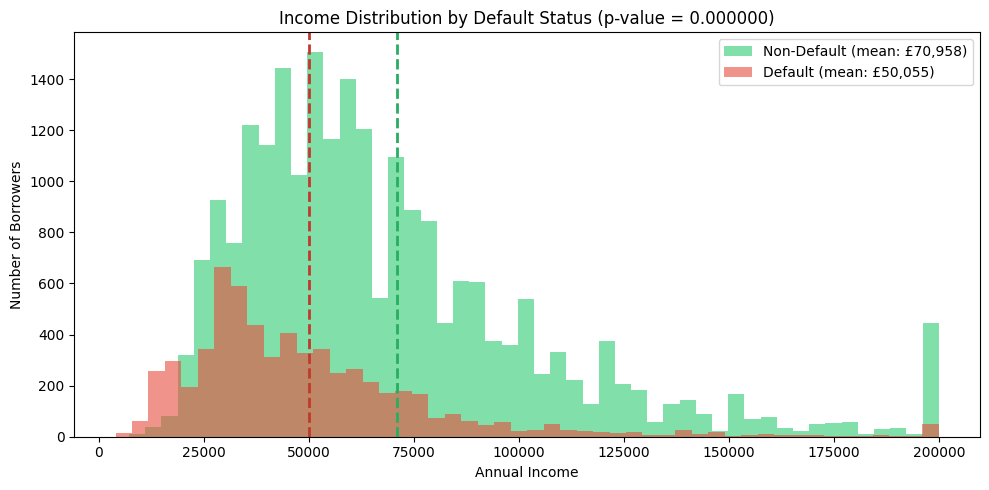

In [ ]:
print("\n" + "="*50)
print("HYPOTHESIS TESTING (t-test)")
print("="*50)

income_non_default = df_clean[df_clean['loan_status'] == 0]['person_income']
income_default = df_clean[df_clean['loan_status'] == 1]['person_income']

t_stat, p_value = stats.ttest_ind(income_non_default, income_default)

print(f"Mean income — Non-Default borrowers: £{income_non_default.mean():,.0f}")
print(f"Mean income — Default borrowers:     £{income_default.mean():,.0f}")
print(f"\nt-statistic: {round(t_stat, 4)}")
print(f"p-value:     {p_value:.6f}")

if p_value < 0.05:
    print(f"\np-value ({p_value:.6f}) < 0.05 — REJECT the null hypothesis.")
    print("There IS a statistically significant difference in income between")
    print("defaulting and non-defaulting borrowers.")
    print("Income is a genuine predictor of default risk.")
else:
    print(f"\np-value ({p_value:.6f}) >= 0.05 — FAIL to reject the null hypothesis.")

plt.figure(figsize=(10, 5))
plt.hist(income_non_default.clip(upper=200000), bins=50, alpha=0.6,
         label=f'Non-Default (mean: £{income_non_default.mean():,.0f})', color='#2ecc71')
plt.hist(income_default.clip(upper=200000), bins=50, alpha=0.6,
         label=f'Default (mean: £{income_default.mean():,.0f})', color='#e74c3c')
plt.axvline(income_non_default.mean(), color='#27ae60', linestyle='--', linewidth=2)
plt.axvline(income_default.mean(), color='#c0392b', linestyle='--', linewidth=2)
plt.title(f'Income Distribution by Default Status (p-value = {p_value:.6f})')
plt.xlabel('Annual Income')
plt.ylabel('Number of Borrowers')
plt.legend()
plt.tight_layout()
plt.savefig('hypothesis_test_income.png', dpi=150, bbox_inches='tight')
plt.show()

FINAL SUMMARY

In [ ]:
print("\n" + "="*60)
print("ANALYSIS COMPLETE — FINAL SUMMARY")
print("="*60)
print(f"Records after cleaning:        {len(df_clean):,}")
print(f"Logistic Regression Accuracy:  {round(lr_accuracy * 100, 2)}%")
print(f"Decision Tree Accuracy:        {round(dt_accuracy * 100, 2)}%")
print(f"Hypothesis test p-value:       {p_value:.6f}")
print(f"Null hypothesis rejected:      {'Yes' if p_value < 0.05 else 'No'}")
print("\nCharts saved:")
print("  exploratory_analysis.png")
print("  logistic_regression_confusion_matrix.png")
print("  logistic_regression_coefficients.png")
print("  decision_tree_confusion_matrix.png")
print("  decision_tree_importance.png")
print("  decision_tree_structure.png")
print("  model_comparison.png")
print("  hypothesis_test_income.png")



ANALYSIS COMPLETE — FINAL SUMMARY
Records after cleaning:        28,633
Logistic Regression Accuracy:  84.09%
Decision Tree Accuracy:        87.29%
Hypothesis test p-value:       0.000000
Null hypothesis rejected:      Yes

Charts saved:
  exploratory_analysis.png
  logistic_regression_confusion_matrix.png
  logistic_regression_coefficients.png
  decision_tree_confusion_matrix.png
  decision_tree_importance.png
  decision_tree_structure.png
  model_comparison.png
  hypothesis_test_income.png
